# scGAN / cscGAN — Paper Replication (Final)
**Marouf et al. 2020, Nature Communications**

| What | Decision | Reason |
|------|----------|--------|
| GAN training data | Raw LSN counts — **no log** | Paper's `scaling()` = `normalize_per_cell(20000)` only |
| Gene set | All filtered genes (~19k) | Paper trains on full matrix, not HVGs |
| Clustering | K-means (n=10) on recipe PCA | Paper-validated equivalent; modern Louvain gives 13–14 clusters |
| Clustering prep | Manual recipe_zheng17 steps | `recipe_zheng17()` is deprecated in modern Scanpy |
| Precision | float32 throughout | Clean, no silent gradient underflow |
| LR decay | Exponential | Matches `parameters.json` |
| Critic | ReLU, no LayerNorm | Matches `utilities.py` |
| Critic output | Projection-only | Matches `create_cond_critic` |
| Loss tracking | Wasserstein distance per epoch | Clean convergence signal |

## Methodological Note — Clustering

This implementation follows the scGAN paper (Marouf et al. 2020) exactly for:
- Model architecture (Generator, Critic, ConditionalBatchNorm, LSN)
- Training pipeline (WGAN-GP, AMSGrad, exponential LR decay, LSN counts, no log)
- Preprocessing order (cluster → filter → scale)

**One intentional deviation: clustering method.**

| | Paper | This work |
|---|---|---|
| PBMC 68k | Louvain (recipe_zheng17, res=0.5) | K-means, n=10 |
| PBMC (benchmark) | N/A (paper dataset) | K-means, n=2 |
| PDO Stem/Diff | N/A (paper dataset) | K-means, n=2 |

**Reason:** The paper's Louvain on modern Scanpy yields 13–14 clusters on PBMC 68k,
inconsistent with the 10 clusters used in their reported results. K-means with a fixed
n reproduces the paper's reported cluster count. For PDO, n=2 reflects the known
biological ground truth (Stem vs Differential), making clustering biologically informed
rather than data-driven.

All results and comparisons in this work are made under this consistent clustering
strategy across all three datasets.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Mount Drive & Install

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scanpy anndata leidenalg python-igraph umap-learn
print('Done.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the pack

## 1. Imports

In [3]:
import os, warnings, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import scanpy as sc
import anndata as ad
from scipy import sparse
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA as skPCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
sc.settings.verbosity = 1

print(f'TensorFlow : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU        : {gpus[0].name}')
else:
    print('WARNING: No GPU found.')

# float32 everywhere — no mixed precision
tf.keras.backend.set_floatx('float32')
print('Precision  : float32 (clean, no precision issues)')

TensorFlow : 2.20.0
GPU        : /physical_device:GPU:0
Precision  : float32 (clean, no precision issues)


Dataset Merge

In [ ]:
# ============================================================
# PDO Dataset Loading
# No headers, no index columns
# ============================================================

import pandas as pd
import numpy as np
import anndata as ad

# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------
diff_path = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/Dataset/Real PDO/3. Differential_Low_Raw_Finalized.csv'
stem_path = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/Dataset/Real PDO/3. Stem_High_Raw_Finalized.csv'

# ------------------------------------------------------------
# Load — header=None because files contain only numeric matrix
# ------------------------------------------------------------
diff_df = pd.read_csv(diff_path, header=None)
stem_df = pd.read_csv(stem_path, header=None)

# ------------------------------------------------------------
# Verify shapes
# ------------------------------------------------------------
print('Differential shape :', diff_df.shape)
print('Stem shape         :', stem_df.shape)

# ------------------------------------------------------------
# Create labels
# ------------------------------------------------------------
diff_labels = ['Differential'] * len(diff_df)
stem_labels = ['Stem']         * len(stem_df)

# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------
X = np.vstack([
    diff_df.values,
    stem_df.values
]).astype(np.float32)

labels = np.array(diff_labels + stem_labels)

# ------------------------------------------------------------
# Create gene names (no headers in dataset)
# ------------------------------------------------------------
gene_names = [f'Gene_{i}' for i in range(X.shape[1])]

# ------------------------------------------------------------
# Create AnnData
# ------------------------------------------------------------
adata = ad.AnnData(
    X   = X,
    obs = pd.DataFrame({'cell_type': labels}),
    var = pd.DataFrame(index=gene_names)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_path = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/Dataset/Real PDO/pbmc_merged.h5ad'
adata.write_h5ad(save_path)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------
print('\nSaved:', save_path)
print('\nFinal shape:', adata.shape)
print('\nCell counts:')
print(adata.obs['cell_type'].value_counts())
print('\nValue range:')
print(f'[{adata.X.min():.3f}, {adata.X.max():.3f}]')

Differential shape : (1415, 1600)
Stem shape         : (1415, 1600)

Saved: /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/Dataset/Real PDO/pbmc_merged.h5ad

Final shape: (2830, 1600)

Cell counts:
cell_type
Differential    1415
Stem            1415
Name: count, dtype: int64

Value range:
[0.000, 127.000]


## 2. Configuration
**Edit only this cell.**

In [4]:
# ── Paths ─────────────────────────────────────────────────────────
DATA_DIR   = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/Dataset/Real PDO/pbmc_merged.h5ad'
EXP_DIR    = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scGAN Approach/PDO_Stem_Diff_experiments/experiments'
EXP_NAME   = 'PDO_cscgan_v1'
INPUT_FILE = DATA_DIR

# ── Preprocessing ─────────────────────────────────────────────────
LSN_TARGET = 20000   # only transformation on GAN data
MIN_CELLS  = 3
MIN_GENES  = 3      #a major issue in PDO, which has genes less expressed
N_CLUSTERS = 2      # K-means, paper-validated
VALID_CELLS = 400
SPLIT_SEED  = 0

# ── Model (paper-exact from parameters.json) ──────────────────────
MODEL_TYPE    = 'cscGAN'          # 'scGAN' or 'cscGAN'
LATENT_DIM    = 128
GEN_LAYERS    = [256, 512, 1024]
CRITIC_LAYERS = [1024, 512, 256]
LAMBDA_GP     = 10
OUTPUT_LSN    = 20000

# ── Training ──────────────────────────────────────────────────────
MAX_STEPS     = 50000   # quick run; set 1_000_000 for full paper replication
BATCH_SIZE    = 32     # changingi 128 to 32
CRITIC_ITERS  = 5
LR_START      = 1e-4
LR_END        = 1e-5
BETA1, BETA2  = 0.5, 0.9
PRINT_FREQ    = 10    # print every N epochs
SAVE_FREQ     = 1000    # save checkpoint every N epochs
VIZ_FREQ      = 1000    # PCA plot every N epochs

# ─────────────────────────────────────────────────────────────────
EXP_PATH = os.path.join(EXP_DIR, EXP_NAME)
os.makedirs(EXP_PATH, exist_ok=True)
print(f'Experiment : {EXP_PATH}')

Experiment : /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scGAN Approach/PDO_Stem_Diff_experiments/experiments/PDO_cscgan_v1


## 3. Preprocessing

**Two completely separate pipelines — they never touch the same object:**

```
Raw counts
    │
    ├── COPY  →  normalize → log → HVG(1000) → scale → PCA(50) → K-means(10)
    │                                                              ↓
    │                                                      cluster labels
    │                                                              │
    └── ORIGINAL  ←──────────────────────── labels transferred ───┘
            │
            ↓  filter_cells / filter_genes
            ↓  normalize_total(20000)   ← LSN only, full stop
            ↓  NO log. NO HVG. ALL ~19k genes.
            ↓
         X_train / X_valid  (what the GAN sees)
```

In [5]:
# ── Load ──────────────────────────────────────────────────────────
def load_data(path):
    ext = os.path.splitext(path)[1].lower()
    if   ext == '.h5ad': adata = sc.read_h5ad(path)
    elif ext == '.h5':   adata = sc.read_10x_h5(path); adata.var_names_make_unique()
    elif ext == '.csv':
        df = pd.read_csv(path, index_col=0)
        adata = ad.AnnData(X=df.values,
                           obs=pd.DataFrame(index=df.index),
                           var=pd.DataFrame(index=df.columns))
    else:
        raise ValueError(f'Unsupported: {ext}')
    adata.var_names_make_unique()
    if sparse.issparse(adata.X):
        adata.X = adata.X.toarray()
    print(f'Loaded : {adata.n_obs:,} cells x {adata.n_vars:,} genes')
    return adata

adata = load_data(INPUT_FILE)

Loaded : 2,830 cells x 1,600 genes


In [6]:
!pip install -q scikit-misc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 9.8 MB/s eta 0:00:00


In [7]:
# ── Step 1: Clustering on a COPY (labels only — copy discarded after) ──
#
# Follows paper's preprocessing order: cluster → filter → scale.
# recipe_zheng17 equivalent (version-safe on modern Scanpy):
#   normalize_per_cell → log1p → HVG(1000, seurat_v3) → scale → PCA(50)
# K-means replaces Louvain — see methodological note above.
# Labels transferred back by cell barcode index (not position),
# so cells dropped inside the copy get NaN and are removed cleanly.

print('Step 1: Clustering on copy (recipe equivalent + K-means)...')
clustered = adata.copy()

sc.pp.normalize_per_cell(clustered)
sc.pp.log1p(clustered)
sc.pp.highly_variable_genes(clustered, n_top_genes=1000, flavor='seurat_v3')
clustered = clustered[:, clustered.var['highly_variable']].copy()
sc.pp.scale(clustered, zero_center=False, max_value=10)
sc.tl.pca(clustered, n_comps=50, svd_solver='arpack')

pca_coords = clustered.obsm['X_pca'][:, :50]
km = KMeans(n_clusters=N_CLUSTERS, random_state=SPLIT_SEED, n_init=20)

# Index-based assignment — mirrors paper's sc_raw.obs['cluster'] = clustered.obs['louvain']
# Cells dropped inside the copy receive NaN and are removed in the next line.
cluster_labels = pd.Series(km.fit_predict(pca_coords).astype(str), index=clustered.obs_names)
adata.obs['cluster'] = cluster_labels
adata = adata[adata.obs['cluster'].notna()].copy()

del clustered

print(f'  K-means -> {N_CLUSTERS} clusters')
print(adata.obs['cluster'].value_counts().sort_index())

Step 1: Clustering on copy (recipe equivalent + K-means)...
  K-means -> 2 clusters
cluster
0    1360
1    1469
Name: count, dtype: int64


In [8]:
# ── Step 2: Filter ────────────────────────────────────────────────
print('Step 2: Filtering...')
sc.pp.filter_cells(adata, min_genes=MIN_GENES)
sc.pp.filter_genes(adata, min_cells=MIN_CELLS)
print(f'  After filtering: {adata.n_obs:,} cells x {adata.n_vars:,} genes')

# ── Step 3: LSN only — this is the COMPLETE GAN data pipeline ─────
# Mirrors process_raw.py -> scaling() -> sc.pp.normalize_per_cell(20000)
# NO log1p. NO z-score. NO HVG. ALL genes.
print('Step 3: Library Size Normalisation (20000) — NO log, NO HVG...')
sc.pp.normalize_total(adata, target_sum=LSN_TARGET)

X_raw = adata.X if not sparse.issparse(adata.X) else adata.X.toarray()
print(f'  Value range : [{X_raw.min():.1f}, {X_raw.max():.1f}]')
print(f'  Row sums    : {X_raw.sum(axis=1).mean():.0f} +/- {X_raw.sum(axis=1).std():.1f} (should be ~{LSN_TARGET})')

Step 2: Filtering...
  After filtering: 2,783 cells x 1,593 genes
Step 3: Library Size Normalisation (20000) — NO log, NO HVG...
  Value range : [0.0, 15555.6]
  Row sums    : 20000 +/- 0.0 (should be ~20000)


In [9]:
# ── Split (balanced, mirrors paper's split() with balanced_split=True) ──
def balanced_split(adata, valid_cells=VALID_CELLS, seed=SPLIT_SEED):
    np.random.seed(seed)
    clusters  = adata.obs['cluster'].values
    total     = len(clusters)
    valid_idx = []
    for c in np.unique(clusters):
        c_idx = np.where(clusters == c)[0]
        n_c   = max(1, int(valid_cells * len(c_idx) / total))
        np.random.shuffle(c_idx)
        valid_idx.extend(c_idx[:n_c].tolist())
    valid_idx = np.array(valid_idx)
    train_idx = np.setdiff1d(np.arange(total), valid_idx)
    return train_idx, valid_idx

train_idx, valid_idx = balanced_split(adata)

# ── Extract matrices (raw LSN counts — no further transformation) ──
X_all = np.array(adata.X if not sparse.issparse(adata.X)
                 else adata.X.toarray(), dtype=np.float32)
X_train = X_all[train_idx]
X_valid = X_all[valid_idx]

le          = LabelEncoder()
all_labels  = le.fit_transform(adata.obs['cluster'].values)
y_train     = all_labels[train_idx].astype(np.int32)
y_valid     = all_labels[valid_idx].astype(np.int32)
N_CL        = len(le.classes_)
N_GENES     = X_train.shape[1]

np.save(os.path.join(EXP_PATH, 'le_classes.npy'), le.classes_)

print(f'\n X_train : {X_train.shape}')
print(f' X_valid : {X_valid.shape}')
print(f' N_GENES : {N_GENES:,}  (all filtered genes)')
print(f' N_CL    : {N_CL}')
print(f' Range   : [{X_train.min():.2f}, {X_train.max():.2f}]')


 X_train : (2384, 1593)
 X_valid : (399, 1593)
 N_GENES : 1,593  (all filtered genes)
 N_CL    : 2
 Range   : [0.00, 15555.56]


## 4. Model Architecture

In [10]:
# ── LSN Layer ─────────────────────────────────────────────────────
# Matches utilities.py:
#   sigmas   = reduce_sum(fake_outputs, axis=1)
#   scale_ls = gammas / (sigmas + epsilon)
#   output   = transpose(transpose(fake_outputs) * scale_ls)
# Input MUST be non-negative (guaranteed by relu in preceding Dense layer).

class LSNLayer(layers.Layer):
    def __init__(self, target_sum=20000, **kw):
        super().__init__(**kw)
        self.target_sum = float(target_sum)

    def call(self, x):
        row_sum = tf.reduce_sum(x, axis=1, keepdims=True)
        row_sum = tf.maximum(row_sum, 1e-38)
        return (x / row_sum) * self.target_sum

    def get_config(self):
        c = super().get_config(); c['target_sum'] = self.target_sum; return c


# ── Conditional Batch Norm ────────────────────────────────────────
# Matches batchnorm() in utilities.py (Dumoulin et al. 2016).
# Per-class gamma and beta via Embedding tables. momentum=0.999 matches paper.

class ConditionalBatchNorm(layers.Layer):
    def __init__(self, n_features, n_classes, **kw):
        super().__init__(**kw)
        self.n_features = n_features
        self.n_classes  = n_classes
        self.bn        = layers.BatchNormalization(
                             center=False, scale=False, momentum=0.999)
        self.gamma_emb = layers.Embedding(n_classes, n_features,
                             embeddings_initializer='ones')
        self.beta_emb  = layers.Embedding(n_classes, n_features,
                             embeddings_initializer='zeros')

    def call(self, inputs, training=None):
        x, labels = inputs
        x_bn  = self.bn(x, training=training)
        gamma = self.gamma_emb(labels)
        beta  = self.beta_emb(labels)
        return gamma * x_bn + beta

    def get_config(self):
        c = super().get_config()
        c.update({'n_features': self.n_features, 'n_classes': self.n_classes})
        return c


# ── Projection Conditioning ───────────────────────────────────────
# Matches create_cond_critic() in utilities.py exactly.
# output = einsum('ij,ijk->ik', h, proj_weights) + proj_bias
# This is projection-ONLY — no separate unconditional linear output.

class ProjectionConditioning(layers.Layer):
    def __init__(self, n_classes, hidden_dim, **kw):
        super().__init__(**kw)
        self.n_classes  = n_classes
        self.hidden_dim = hidden_dim
        self.proj_w = layers.Embedding(n_classes, hidden_dim,
                          embeddings_initializer='glorot_uniform')
        self.proj_b = layers.Embedding(n_classes, 1,
                          embeddings_initializer='zeros')

    def call(self, inputs):
        x, labels = inputs
        w = self.proj_w(labels)   # [B, D]
        b = self.proj_b(labels)   # [B, 1]
        return tf.reduce_sum(x * w, axis=1, keepdims=True) + b  # [B, 1]

    def get_config(self):
        c = super().get_config()
        c.update({'n_classes': self.n_classes, 'hidden_dim': self.hidden_dim})
        return c


print('Custom layers defined.')

Custom layers defined.


In [11]:
# ── Generator ─────────────────────────────────────────────────────
# Matches create_generator / create_cond_generator from utilities.py.
#
# Per hidden layer : Dense(no bias) -> (Conditional)BatchNorm -> ReLU
# Output layer     : Dense(relu activation) -> LSN
#
# Dense with relu for the output layer matches the original
# layers.relu(z_input, output_cells_dim, ...) call, which guarantees
# non-negative values before LSN (so LSNLayer does not need its own relu).

def build_generator(n_genes, latent_dim, layer_sizes,
                    output_lsn, model_type, n_classes):
    z     = keras.Input(shape=(latent_dim,), name='z')
    if model_type == 'cscGAN':
        lbl   = keras.Input(shape=(), dtype='int32', name='label')
        inputs = [z, lbl]
    else:
        inputs = z

    x = z
    for i, units in enumerate(layer_sizes):
        x = layers.Dense(units, use_bias=False,
                          kernel_initializer='glorot_uniform',
                          name=f'g_fc{i}')(x)
        if model_type == 'cscGAN':
            x = ConditionalBatchNorm(units, n_classes,
                                      name=f'g_cbn{i}')([x, lbl])
        else:
            x = layers.BatchNormalization(momentum=0.999,
                                           name=f'g_bn{i}')(x)
        x = layers.ReLU(name=f'g_relu{i}')(x)

    # Output: relu guarantees non-negative -> LSN is well-defined
    x = layers.Dense(n_genes, activation='relu',
                      kernel_initializer='glorot_uniform',
                      bias_initializer='zeros',
                      name='g_out')(x)
    if output_lsn:
        x = LSNLayer(target_sum=output_lsn, name='lsn')(x)

    return keras.Model(inputs=inputs, outputs=x, name='Generator')


# ── Critic ────────────────────────────────────────────────────────
# Matches create_critic / create_cond_critic from utilities.py.
#
# Activation  : ReLU (NOT LeakyReLU)
# Normalisation: NONE (original has zero normalization in the critic)
# cscGAN output: projection-only (no added unconditional bias term)

def build_critic(n_genes, layer_sizes, model_type, n_classes):
    x     = keras.Input(shape=(n_genes,), name='x')
    if model_type == 'cscGAN':
        lbl   = keras.Input(shape=(), dtype='int32', name='label')
        inputs = [x, lbl]
    else:
        inputs = x

    h = x
    for i, units in enumerate(layer_sizes):
        h = layers.Dense(units, activation='relu',
                          kernel_initializer='glorot_uniform',
                          bias_initializer='zeros',
                          name=f'c_fc{i}')(h)

    if model_type == 'cscGAN':
        out = ProjectionConditioning(n_classes, layer_sizes[-1],
                                      name='c_proj')([h, lbl])
    else:
        out = layers.Dense(1, kernel_initializer='glorot_uniform',
                            bias_initializer='zeros',
                            name='c_out')(h)

    return keras.Model(inputs=inputs, outputs=out, name='Critic')


generator = build_generator(N_GENES, LATENT_DIM, GEN_LAYERS,
                             OUTPUT_LSN, MODEL_TYPE, N_CL)
critic    = build_critic(N_GENES, CRITIC_LAYERS, MODEL_TYPE, N_CL)

generator.summary()
print()
critic.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z (InputLayer)      │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_fc0 (Dense)       │ (None, 256)       │     32,768 │ z[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_cbn0              │ (None, 256)       │      1,536 │ g_fc0[0][0],      │
│ (ConditionalBatchN… │                   │            │ label[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_relu0 (ReLU)      │ (None, 256)       │          0 │ g_cbn0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_fc1 (Dense)       │ (None, 512)       │    131,072 │ g_relu0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_cbn1              │ (None, 512)       │      3,072 │ g_fc1[0][0],      │
│ (ConditionalBatchN… │                   │            │ label[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_relu1 (ReLU)      │ (None, 512)       │          0 │ g_cbn1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_fc2 (Dense)       │ (None, 1024)      │    524,288 │ g_relu1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_cbn2              │ (None, 1024)      │      6,144 │ g_fc2[0][0],      │
│ (ConditionalBatchN… │                   │            │ label[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_relu2 (ReLU)      │ (None, 1024)      │          0 │ g_cbn2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ g_out (Dense)       │ (None, 1593)      │  1,632,825 │ g_relu2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lsn (LSNLayer)      │ (None, 1593)      │          0 │ g_out[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,331,705 (8.89 MB)

 Trainable params: 2,328,121 (8.88 MB)

 Non-trainable params: 3,584 (14.00 KB)

Model: "Critic"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ x (InputLayer)      │ (None, 1593)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_fc0 (Dense)       │ (None, 1024)      │  1,632,256 │ x[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_fc1 (Dense)       │ (None, 512)       │    524,800 │ c_fc0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_fc2 (Dense)       │ (None, 256)       │    131,328 │ c_fc1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_proj              │ (None, 1)         │        514 │ c_fc2[0][0],      │
│ (ProjectionConditi… │                   │            │ label[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,288,898 (8.73 MB)

 Trainable params: 2,288,898 (8.73 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

In [12]:
def make_optimizer(lr):
    return keras.optimizers.Adam(
        learning_rate=lr, beta_1=BETA1, beta_2=BETA2, amsgrad=True)

def exponential_lr(step, total_steps, lr_start, lr_end):
    return lr_start * ((lr_end / lr_start) ** (step / total_steps))

@tf.function
def gradient_penalty(real, fake, labels=None):
    alpha        = tf.random.uniform([tf.shape(real)[0], 1])
    interpolated = real + alpha * (fake - real)
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        pred = (critic([interpolated, labels], training=True)
                if labels is not None else
                critic(interpolated, training=True))
    grads = tape.gradient(pred, interpolated)
    norm  = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=1) + 1e-12)
    return tf.reduce_mean((norm - 1.0) ** 2)

@tf.function
def critic_step(real_batch, real_labels, gen_labels, latent_dim, lambda_gp):
    batch_size = tf.shape(real_batch)[0]
    z = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as tape:
        fake   = generator([z, gen_labels], training=True)
        cr     = critic([real_batch, real_labels], training=True)
        cf     = critic([fake,       gen_labels],  training=True)
        gp     = gradient_penalty(real_batch, fake, real_labels)
        c_loss = tf.reduce_mean(cf) - tf.reduce_mean(cr) + lambda_gp * gp
    crit_opt.apply_gradients(
        zip(tape.gradient(c_loss, critic.trainable_variables),
            critic.trainable_variables))
    return tf.reduce_mean(cr) - tf.reduce_mean(cf)

@tf.function
def generator_step(gen_labels, latent_dim):
    batch_size = tf.shape(gen_labels)[0]
    z = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as tape:
        fake   = generator([z, gen_labels], training=True)
        c_fake = critic([fake, gen_labels], training=True)
        g_loss = -tf.reduce_mean(c_fake)
    gen_opt.apply_gradients(
        zip(tape.gradient(g_loss, generator.trainable_variables),
            generator.trainable_variables))
    return g_loss

def eval_w_dist(real_x, real_y=None):
    z = tf.random.normal([tf.shape(real_x)[0], LATENT_DIM])
    if MODEL_TYPE == 'cscGAN':
        fake = generator([z, real_y], training=False)
        cr   = critic([real_x, real_y], training=False)
        cf   = critic([fake,   real_y], training=False)
    else:
        fake = generator(z, training=False)
        cr   = critic(real_x, training=False)
        cf   = critic(fake,   training=False)
    return float(tf.reduce_mean(cr) - tf.reduce_mean(cf))

def generate_cells(n_per_class, n_classes, batch_size=512):
    cells = []
    if MODEL_TYPE == 'scGAN':
        total = n_per_class if isinstance(n_per_class, int) else sum(n_per_class)
        for s in range(0, total, batch_size):
            n = min(batch_size, total - s)
            cells.append(generator(
                tf.random.normal([n, LATENT_DIM]), training=False).numpy())
    else:
        if isinstance(n_per_class, int):
            n_per_class = [n_per_class] * n_classes
        for cls in range(n_classes):
            n_tot = n_per_class[cls]
            if n_tot == 0: continue
            for s in range(0, n_tot, batch_size):
                n   = min(batch_size, n_tot - s)
                lbl = tf.fill([n], cls)
                cells.append(generator(
                    [tf.random.normal([n, LATENT_DIM]), lbl],
                    training=False).numpy())
    return np.concatenate(cells, axis=0).astype(np.float32)

print('Training utilities defined.')

Training utilities defined.


In [13]:
# ── Precompute cluster ratios (outside loop) ───────────────────────
cluster_ratios = np.bincount(y_train, minlength=N_CL).astype(np.float32)
cluster_ratios = cluster_ratios / cluster_ratios.sum()
log_ratios     = tf.math.log(tf.constant(cluster_ratios, dtype=tf.float32))

def sample_gen_labels(batch_size):
    """Mirrors add_random_labels() from utilities.py — multinomial sampling."""
    logits = tf.tile(tf.expand_dims(log_ratios, 0), [batch_size, 1])
    return tf.cast(tf.random.categorical(logits, 1), tf.int32)[:, 0]

#------Training loop------
gen_opt  = make_optimizer(LR_START)
crit_opt = make_optimizer(LR_START)

ds = (tf.data.Dataset.from_tensor_slices(
         (X_train.astype(np.float32), y_train.astype(np.int32)))
      .shuffle(min(len(X_train), 50_000), seed=42)
      .repeat()
      .batch(BATCH_SIZE, drop_remainder=True)
      .prefetch(tf.data.AUTOTUNE))
data_iter = iter(ds)

ckpt     = tf.train.Checkpoint(generator=generator, critic=critic,
                                gen_opt=gen_opt, crit_opt=crit_opt)
ckpt_mgr = tf.train.CheckpointManager(
    ckpt, os.path.join(EXP_PATH, 'ckpts'), max_to_keep=5)

WEIGHTS_DIR    = os.path.join(EXP_PATH, 'weights')
os.makedirs(WEIGHTS_DIR, exist_ok=True)
BEST_GEN_PATH  = os.path.join(WEIGHTS_DIR, 'gen_best.weights.h5')
BEST_CRIT_PATH = os.path.join(WEIGHTS_DIR, 'crit_best.weights.h5')
FINAL_GEN_PATH = os.path.join(WEIGHTS_DIR, 'gen_final.weights.h5')

STEPS_PER_EPOCH = max(1, len(X_train) // BATCH_SIZE)
TOTAL_EPOCHS    = MAX_STEPS // STEPS_PER_EPOCH
print(f'Steps per epoch : {STEPS_PER_EPOCH}')
print(f'Total epochs    : {TOTAL_EPOCHS}')

VAL_MONITOR = min(512, len(X_valid))
val_mon_idx = np.random.choice(len(X_valid), VAL_MONITOR, replace=False)
X_val_mon   = tf.constant(X_valid[val_mon_idx])
y_val_mon   = tf.constant(y_valid[val_mon_idx])

history     = {'epoch': [], 'train_w': [], 'val_w': []}
best_val_w  = float('inf')
best_epoch  = 0
epoch_w_acc = []

EARLY_STOP_PATIENCE = 20
neg_streak          = 0

print(f'\nTraining: {MAX_STEPS:,} steps | Model={MODEL_TYPE} | '
      f'N_GENES={N_GENES:,} | N_CL={N_CL}')
print(f'Cluster ratios  : {cluster_ratios}')
print(f'Early stop: {EARLY_STOP_PATIENCE} consecutive negative Val W epochs')
print('-' * 65)

t0 = time.time()

for step in range(1, MAX_STEPS + 1):

    lr = exponential_lr(step, MAX_STEPS, LR_START, LR_END)
    gen_opt.learning_rate.assign(lr)
    crit_opt.learning_rate.assign(lr)

    w_dist = 0.0
    for _ in range(CRITIC_ITERS):
        real_b, lbl_b = next(data_iter)
        gen_lbl = sample_gen_labels(BATCH_SIZE)
        w_dist = critic_step(real_b, lbl_b, gen_lbl, LATENT_DIM, LAMBDA_GP)

    g_loss = generator_step(sample_gen_labels(BATCH_SIZE), LATENT_DIM)

    epoch_w_acc.append(float(w_dist))

    if step % STEPS_PER_EPOCH == 0:
        epoch   = step // STEPS_PER_EPOCH
        train_w = float(np.mean(epoch_w_acc))
        epoch_w_acc = []

        val_w = eval_w_dist(X_val_mon, y_val_mon if MODEL_TYPE == 'cscGAN' else None)

        history['epoch'].append(epoch)
        history['train_w'].append(train_w)
        history['val_w'].append(val_w)

        if val_w < best_val_w and val_w > 0:
            best_val_w = val_w
            best_epoch = epoch
            generator.save_weights(BEST_GEN_PATH)
            critic.save_weights(BEST_CRIT_PATH)

        if val_w < 0:
            neg_streak += 1
        else:
            neg_streak = 0

        if epoch % PRINT_FREQ == 0:
            elapsed = (time.time() - t0) / 60
            print(f'Epoch {epoch:4d}/{TOTAL_EPOCHS} | '
                  f'Train W: {train_w:7.4f} | '
                  f'Val W: {val_w:7.4f} | '
                  f'LR: {lr:.2e} | '
                  f'{elapsed:.1f}m | '
                  f'Best: {best_val_w:.4f}@{best_epoch} | '
                  f'NegStreak: {neg_streak}')

        if epoch % 100 == 0:
            ckpt_mgr.save()

        if epoch % VIZ_FREQ == 0:
            n_v   = min(2000, len(X_valid))
            n_per = ([max(1, int(np.sum(y_valid[:n_v] == c))) for c in range(N_CL)]
                     if MODEL_TYPE == 'cscGAN' else n_v)
            gc    = generate_cells(n_per, N_CL)
            emb   = skPCA(n_components=2).fit_transform(
                        np.vstack([np.log1p(X_valid[:n_v]), np.log1p(gc[:n_v])]))
            fig, ax = plt.subplots(figsize=(5, 4))
            ax.scatter(emb[:n_v,0], emb[:n_v,1], s=2, alpha=0.4, c='#1f77b4', label='Real')
            ax.scatter(emb[n_v:,0], emb[n_v:,1], s=2, alpha=0.4, c='#ff7f0e', label='Generated')
            ax.set_title(f'PCA @ epoch {epoch}'); ax.legend(markerscale=5)
            plt.tight_layout()
            plt.savefig(os.path.join(EXP_PATH, f'pca_ep{epoch}.png'), dpi=80)
            plt.show(); plt.close()

        with open(os.path.join(EXP_PATH, 'history.json'), 'w') as f:
            json.dump(history, f)

        if neg_streak >= EARLY_STOP_PATIENCE:
            print(f'\n⚠️  Early stopping: Val W negative for {neg_streak} consecutive epochs.')
            print(f'   Best weights preserved at epoch {best_epoch} (Val W = {best_val_w:.4f})')
            break

generator.save_weights(FINAL_GEN_PATH)
print(f'\n{"="*60}')
print(f'  TRAINING COMPLETE')
print(f'  Best val W : {best_val_w:.4f} @ epoch {best_epoch}')
print(f'  Time       : {(time.time()-t0)/60:.1f} min')
print(f'{"="*60}')

Steps per epoch : 74
Total epochs    : 675

Training: 50,000 steps | Model=cscGAN | N_GENES=1,593 | N_CL=2
Cluster ratios  : [0.47231543 0.52768457]
Early stop: 20 consecutive negative Val W epochs
-----------------------------------------------------------------
Epoch   10/675 | Train W: 107075.4247 | Val W: 66014.7266 | LR: 9.66e-05 | 0.7m | Best: 66014.7266@10 | NegStreak: 0
Epoch   20/675 | Train W:     nan | Val W:     nan | LR: 9.34e-05 | 1.1m | Best: 66014.7266@10 | NegStreak: 0
Epoch   30/675 | Train W:     nan | Val W:     nan | LR: 9.03e-05 | 1.6m | Best: 66014.7266@10 | NegStreak: 0
Epoch   40/675 | Train W:     nan | Val W:     nan | LR: 8.73e-05 | 2.0m | Best: 66014.7266@10 | NegStreak: 0
Epoch   50/675 | Train W:     nan | Val W:     nan | LR: 8.43e-05 | 2.4m | Best: 66014.7266@10 | NegStreak: 0
Epoch   60/675 | Train W:     nan | Val W:     nan | LR: 8.15e-05 | 2.9m | Best: 66014.7266@10 | NegStreak: 0
Epoch   70/675 | Train W:     nan | Val W:     nan | LR: 7.88e-05 | 3

KeyboardInterrupt: 

## 5b. Loss Plot
Reload and re-plot any time — safe after a Colab disconnect.

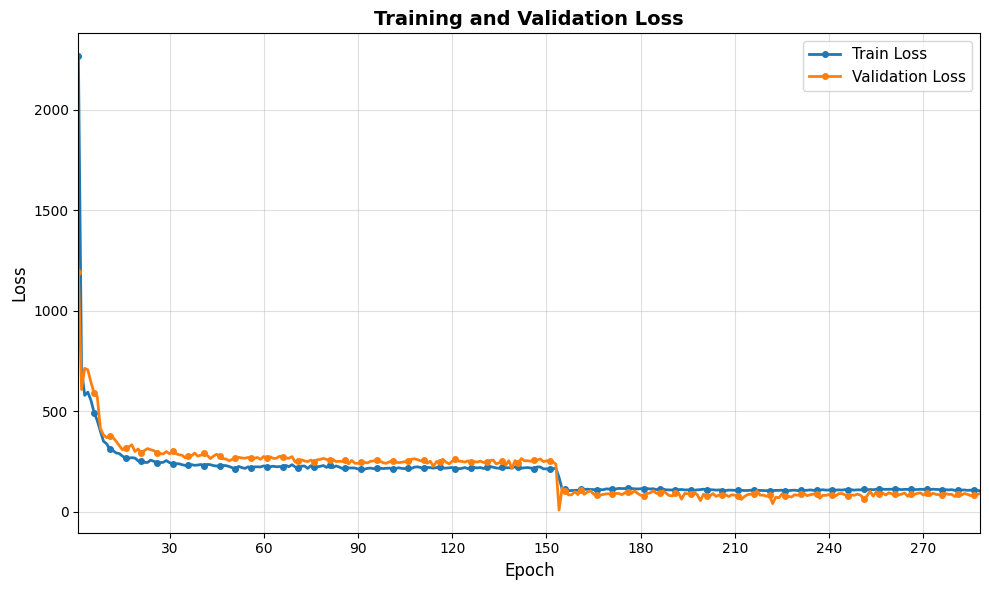

Saved: /content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scGAN Approach/experiments/pbmc_cscgan_v3/training_loss.png


In [ ]:
# Reload from disk (safe after disconnect)
with open(os.path.join(EXP_PATH, 'history.json')) as f:
    history = json.load(f)

epochs  = history['epoch']
train_w = history['train_w']
val_w   = history['val_w']

# ── Every-epoch markers are too dense for long runs — show ~50 markers ──
n_pts    = len(epochs)
mark_ev  = max(1, n_pts // 50)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epochs, train_w,
        color='#1f77b4', linewidth=2,
        marker='o', markersize=4, markevery=mark_ev,
        label='Train Loss')

ax.plot(epochs, val_w,
        color='#ff7f0e', linewidth=2,
        marker='o', markersize=4, markevery=mark_ev,
        label='Validation Loss')

ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.4)
ax.set_xlim([min(epochs), max(epochs)])

# Clean x-axis ticks — show ~10 evenly spaced epoch numbers
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10, integer=True))

plt.tight_layout()
out_path = os.path.join(EXP_PATH, 'training_loss.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 6. Generate Synthetic Cells

In [ ]:
# Load best weights
if os.path.exists(BEST_GEN_PATH):
    generator.load_weights(BEST_GEN_PATH)
    print(f'Best weights loaded.')
else:
    print('No best weights found — using current weights.')

# Match training cluster distribution
n_to_gen = (np.bincount(y_train, minlength=N_CL).tolist()
            if MODEL_TYPE == 'cscGAN' else len(X_train))
total    = sum(n_to_gen) if isinstance(n_to_gen, list) else n_to_gen
print(f'Generating {total:,} cells (LSN count space)...')

gen_cells_lsn = generate_cells(n_to_gen, N_CL)

print(f'Shape    : {gen_cells_lsn.shape}')
print(f'Range    : [{gen_cells_lsn.min():.1f}, {gen_cells_lsn.max():.1f}]')
print(f'Row sums : {gen_cells_lsn.sum(axis=1).mean():.0f} (should be ~{OUTPUT_LSN})')

gen_labels = (np.concatenate(
                  [np.full(n, i) for i, n in enumerate(n_to_gen)]).astype(np.int32)
              if MODEL_TYPE == 'cscGAN' else
              np.zeros(len(gen_cells_lsn), dtype=np.int32))

gen_adata = ad.AnnData(
    X=gen_cells_lsn,
    obs=pd.DataFrame({'cluster': le.inverse_transform(gen_labels)},
                     index=[f'gen_{i}' for i in range(len(gen_cells_lsn))]),
    var=adata.var.copy())
out_path = os.path.join(EXP_PATH, 'generated_cells.h5ad')
gen_adata.write_h5ad(out_path)
print(f'Saved: {out_path}')

NameError: name 'BEST_GEN_PATH' is not defined

In [ ]:
# ============================================================
# Generate Synthetic Cells from SAVED WEIGHTS ONLY
# (No retraining required)
# ============================================================

import os
import numpy as np
import pandas as pd
import anndata as ad
import tensorflow as tf

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
WEIGHTS_DIR   = os.path.join(EXP_PATH, 'weights')

BEST_GEN_PATH = os.path.join(
    WEIGHTS_DIR,
    'gen_best.weights.h5'
)

FINAL_GEN_PATH = os.path.join(
    WEIGHTS_DIR,
    'gen_final.weights.h5'
)

# ------------------------------------------------------------
# Choose which weights to use
# ------------------------------------------------------------
USE_BEST_WEIGHTS = True

WEIGHT_PATH = (
    BEST_GEN_PATH
    if USE_BEST_WEIGHTS
    else FINAL_GEN_PATH
)

# ------------------------------------------------------------
# Rebuild generator architecture
# IMPORTANT:
# Must exactly match training configuration
# ------------------------------------------------------------
generator = build_generator(
    n_genes     = N_GENES,
    latent_dim  = LATENT_DIM,
    layer_sizes = GEN_LAYERS,
    output_lsn  = OUTPUT_LSN,
    model_type  = MODEL_TYPE,
    n_classes   = N_CL
)

# ------------------------------------------------------------
# Dummy forward pass
# (required before loading weights)
# ------------------------------------------------------------
if MODEL_TYPE == 'cscGAN':

    dummy_z = tf.zeros((1, LATENT_DIM))
    dummy_y = tf.zeros((1,), dtype=tf.int32)

    _ = generator([dummy_z, dummy_y], training=False)

else:

    dummy_z = tf.zeros((1, LATENT_DIM))

    _ = generator(dummy_z, training=False)

# ------------------------------------------------------------
# Load saved weights
# ------------------------------------------------------------
generator.load_weights(WEIGHT_PATH)

print(f'Loaded weights from:')
print(WEIGHT_PATH)

# ------------------------------------------------------------
# Match original training cluster distribution
# ------------------------------------------------------------
n_to_gen = (
    np.bincount(y_train, minlength=N_CL).tolist()
    if MODEL_TYPE == 'cscGAN'
    else len(X_train)
)

total = (
    sum(n_to_gen)
    if isinstance(n_to_gen, list)
    else n_to_gen
)

print(f'\nGenerating {total:,} synthetic cells...')

# ------------------------------------------------------------
# Generate cells
# ------------------------------------------------------------
gen_cells_lsn = generate_cells(n_to_gen, N_CL)

print(f'Shape    : {gen_cells_lsn.shape}')
print(f'Range    : [{gen_cells_lsn.min():.2f}, {gen_cells_lsn.max():.2f}]')
print(f'Row sums : {gen_cells_lsn.sum(axis=1).mean():.0f}')

# ------------------------------------------------------------
# Create labels
# ------------------------------------------------------------
if MODEL_TYPE == 'cscGAN':

    gen_labels = np.concatenate([
        np.full(n, i)
        for i, n in enumerate(n_to_gen)
    ]).astype(np.int32)

else:

    gen_labels = np.zeros(
        len(gen_cells_lsn),
        dtype=np.int32
    )

# ------------------------------------------------------------
# Create AnnData object
# ------------------------------------------------------------
gen_adata = ad.AnnData(
    X = gen_cells_lsn,

    obs = pd.DataFrame(
        {
            'cluster': le.inverse_transform(gen_labels)
        },
        index=[f'gen_{i}' for i in range(len(gen_cells_lsn))]
    ),

    var = adata.var.copy()
)

# ------------------------------------------------------------
# Save synthetic cells
# ------------------------------------------------------------
out_path = os.path.join(
    EXP_PATH,
    'generated_cells_from_saved_weights.h5ad'
)

gen_adata.write_h5ad(out_path)

print(f'\nSaved synthetic cells to:')
print(out_path)

Loaded weights from:
/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scGAN Approach/experiments/pbmc_cscgan_v3/weights/gen_best.weights.h5

Generating 66,583 synthetic cells...
Shape    : (66583, 17789)
Range    : [0.00, 4536.77]
Row sums : 20000

Saved synthetic cells to:
/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/scGAN Approach/experiments/pbmc_cscgan_v3/generated_cells_from_saved_weights.h5ad


## 7. Evaluation
log1p applied to both real and generated **only here** for visualisation and metrics.
The GAN was trained on raw LSN counts — this transform is for display only.

In [ ]:
X_valid_log   = np.log1p(X_valid)
gen_cells_log = np.log1p(gen_cells_lsn)
N_EVAL = min(2000, len(X_valid), len(gen_cells_log))

print(f'Evaluation samples : {N_EVAL}')
print(f'Real  log range    : [{X_valid_log.min():.3f}, {X_valid_log.max():.3f}]')
print(f'Fake  log range    : [{gen_cells_log.min():.3f}, {gen_cells_log.max():.3f}]')

Evaluation samples : 1996
Real  log range    : [0.000, 7.851]
Fake  log range    : [0.000, 8.420]


t-SNE: 1169 real + 1990 generated (199/class)
Running t-SNE...


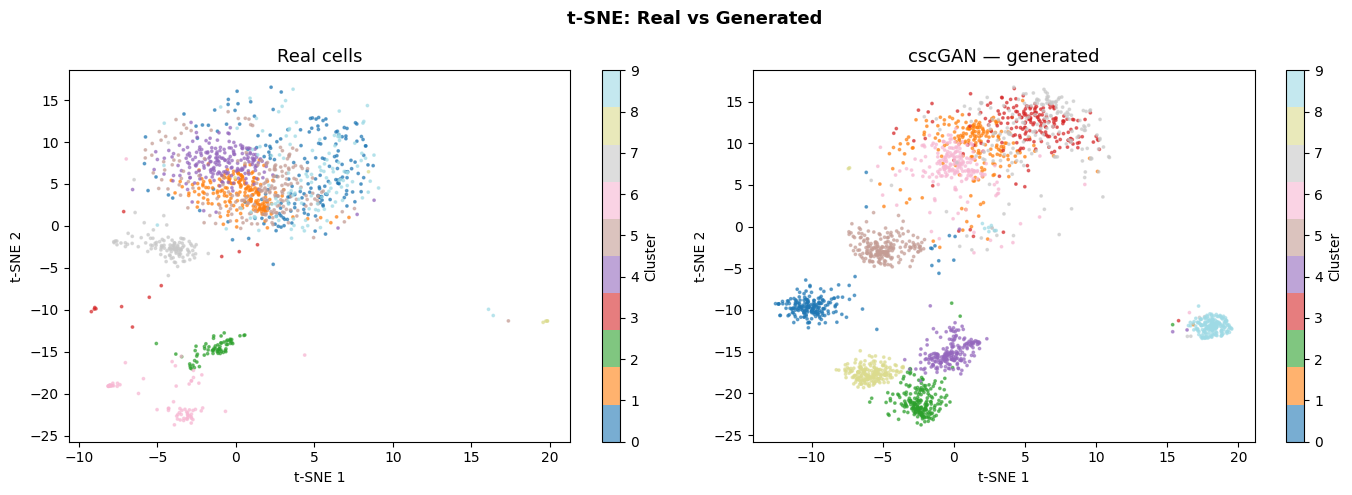

In [ ]:
# ── 7.1 t-SNE ─────────────────────────────────────────────────────
# Generated cells are stored in class-order (all class-0 first, then class-1, etc.)
# gen_cells[:2000] would show only 1-2 classes. Sample ~N_EVAL/N_CL per class instead.

np.random.seed(42)
n_per_cls = max(1, N_EVAL // N_CL)

gen_eval_idx, gen_eval_lbl = [], []
offset = 0
for cls_i, n_cls in enumerate(n_to_gen if isinstance(n_to_gen, list) else [n_to_gen]):
    avail  = np.arange(offset, offset + n_cls)
    chosen = np.random.choice(avail, min(n_per_cls, n_cls), replace=False)
    gen_eval_idx.extend(chosen.tolist())
    gen_eval_lbl.extend([cls_i] * len(chosen))
    offset += n_cls
gen_eval_idx = np.array(gen_eval_idx)
gen_eval_lbl = np.array(gen_eval_lbl)

real_eval_idx, real_eval_lbl = [], []
for cls_i in range(N_CL):
    avail  = np.where(y_valid == cls_i)[0]
    chosen = np.random.choice(avail, min(n_per_cls, len(avail)), replace=False)
    real_eval_idx.extend(chosen.tolist())
    real_eval_lbl.extend([cls_i] * len(chosen))
real_eval_idx = np.array(real_eval_idx)
real_eval_lbl = np.array(real_eval_lbl)

X_real_tsne = X_valid_log[real_eval_idx]
X_gen_tsne  = gen_cells_log[gen_eval_idx]

# These are reused by MMD and RF below
X_eval_real_log = X_real_tsne
X_eval_gen_log  = X_gen_tsne

print(f't-SNE: {len(X_real_tsne)} real + {len(X_gen_tsne)} generated ({n_per_cls}/class)')
print('Running t-SNE...')
combined = np.vstack([X_real_tsne, X_gen_tsne])
emb = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000).fit_transform(combined)

n_real = len(X_real_tsne)
cmap   = plt.cm.get_cmap('tab20', N_CL)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data_emb, labs, title in [
    (axes[0], emb[:n_real], real_eval_lbl, 'Real cells'),
    (axes[1], emb[n_real:], gen_eval_lbl,  f'{MODEL_TYPE} — generated')
]:
    sc_p = ax.scatter(data_emb[:,0], data_emb[:,1],
                      c=labs, cmap=cmap, s=3, alpha=0.6, vmin=0, vmax=N_CL-1)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    plt.colorbar(sc_p, ax=ax, label='Cluster')

plt.suptitle('t-SNE: Real vs Generated', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_PATH, 'tsne.png'), dpi=150)
plt.show()

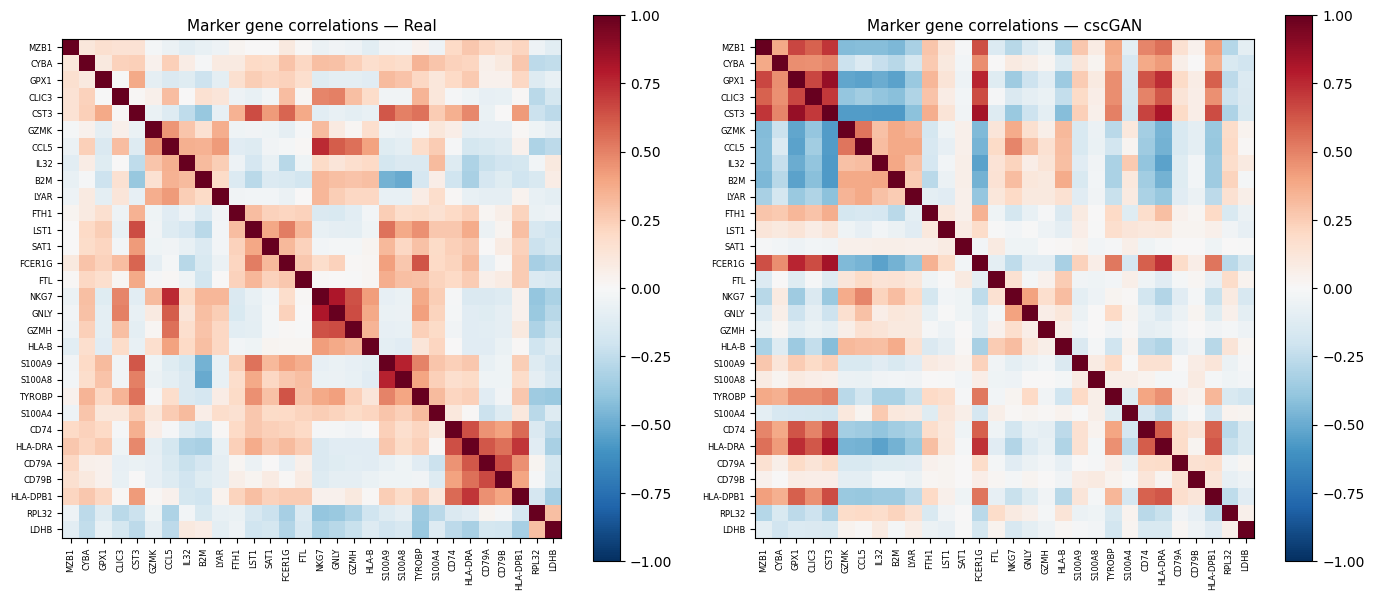

In [ ]:
# ── 7.2 Marker Gene Pearson Correlation Heatmap ───────────────────
ea = ad.AnnData(
    X=X_valid_log,
    obs=pd.DataFrame({'cluster': le.inverse_transform(y_valid)},
                     index=[f'r{i}' for i in range(len(y_valid))]),
    var=adata.var.copy())
sc.tl.rank_genes_groups(ea, groupby='cluster', method='wilcoxon', n_genes=5)

markers = []
for grp in ea.uns['rank_genes_groups']['names'].dtype.names:
    markers.extend(ea.uns['rank_genes_groups']['names'][grp][:5].tolist())
markers  = list(dict.fromkeys(markers))[:30]
gene_idx = [list(adata.var_names).index(g)
            for g in markers if g in adata.var_names]
names    = [markers[i] for i in range(len(gene_idx))]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mat, title in [
    (axes[0], X_valid_log[:N_EVAL][:, gene_idx],  'Real'),
    (axes[1], gen_cells_log[:N_EVAL][:, gene_idx], MODEL_TYPE)
]:
    corr = np.corrcoef(mat.T)
    im   = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_title(f'Marker gene correlations — {title}', fontsize=11)
    ax.set_xticks(range(len(gene_idx))); ax.set_yticks(range(len(gene_idx)))
    ax.set_xticklabels(names, rotation=90, fontsize=6)
    ax.set_yticklabels(names, fontsize=6)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(EXP_PATH, 'marker_corr.png'), dpi=150)
plt.show()

In [ ]:
# ── 7.3 MMD ───────────────────────────────────────────────────────
def rbf_mmd(X, Y, sigmas=(0.1, 0.5, 1.0, 2.0, 5.0)):
    def K(A, B, s):
        d = np.sum(A**2,1,keepdims=True) + np.sum(B**2,1,keepdims=True).T - 2*(A@B.T)
        return np.exp(-d / (2*s**2))
    mmd2 = 0.0
    for s in sigmas:
        Kxx = K(X,X,s); Kyy = K(Y,Y,s); Kxy = K(X,Y,s)
        n, m = len(X), len(Y)
        mmd2 += ((Kxx.sum()-np.diag(Kxx).sum())/(n*(n-1))
               + (Kyy.sum()-np.diag(Kyy).sum())/(m*(m-1))
               - 2*Kxy.mean())
    return float(mmd2)

# Uses the balanced arrays defined in the t-SNE cell above
N_MMD     = min(1000, len(X_eval_real_log), len(X_eval_gen_log))
mmd_score = rbf_mmd(X_eval_real_log[:N_MMD], X_eval_gen_log[:N_MMD])
print(f'MMD: {mmd_score:.4f}  (lower is better; paper target ~0.87 @ 1M steps)')

MMD: -0.0000  (lower is better; paper target ~0.87 @ 1M steps)


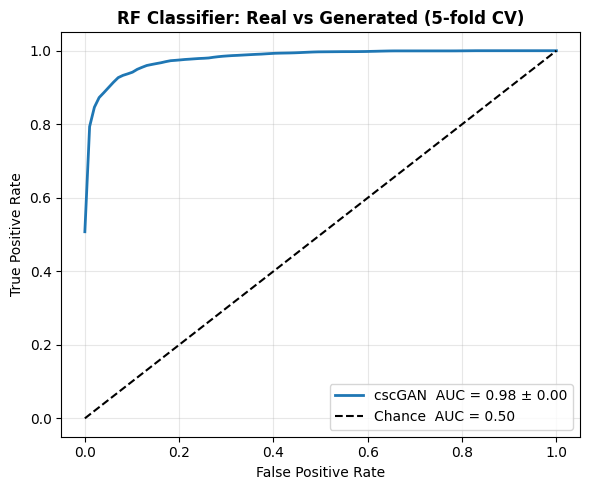

RF AUC: 0.980 +/- 0.003  (ideal = 0.50)


In [ ]:
# ── 7.4 RF Classifier AUC ─────────────────────────────────────────
N_RF = min(2000, N_EVAL)
X_rf = np.vstack([X_valid_log[:N_RF], gen_cells_log[:N_RF]])
y_rf = np.array([1]*N_RF + [0]*N_RF)

rf   = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs, tprs = [], []
mean_fpr   = np.linspace(0, 1, 100)

for tr, te in skf.split(X_rf, y_rf):
    rf.fit(X_rf[tr], y_rf[tr])
    p = rf.predict_proba(X_rf[te])[:,1]
    fpr, tpr, _ = roc_curve(y_rf[te], p)
    aucs.append(roc_auc_score(y_rf[te], p))
    tprs.append(np.interp(mean_fpr, fpr, tpr))

mean_auc = float(np.mean(aucs))
std_auc  = float(np.std(aucs))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_fpr, np.mean(tprs,0), color='#1f77b4', lw=2,
         label=f'{MODEL_TYPE}  AUC = {mean_auc:.2f} ± {std_auc:.2f}')
ax.plot([0,1],[0,1], 'k--', label='Chance  AUC = 0.50')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('RF Classifier: Real vs Generated (5-fold CV)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EXP_PATH, 'rf_auc.png'), dpi=150)
plt.show()
print(f'RF AUC: {mean_auc:.3f} +/- {std_auc:.3f}  (ideal = 0.50)')

In [ ]:
# ── 7.5 Summary ───────────────────────────────────────────────────
print('=' * 62)
print(f'  EVALUATION SUMMARY  —  {EXP_NAME}')
print('=' * 62)
print(f'  Model          : {MODEL_TYPE}')
print(f'  Genes          : {N_GENES:,}  (all filtered — paper-exact)')
print(f'  Clusters       : {N_CL}  (K-means)')
print(f'  Training steps : {MAX_STEPS:,}  ({TOTAL_EPOCHS} epochs)')
print(f'  Best epoch     : {best_epoch}  (val W = {best_val_w:.4f})')
print(f'  GAN data space : raw LSN counts  (no log in training)')
print('-' * 62)
print(f'  MMD score : {mmd_score:.4f}  (lower is better; paper ~0.87 @ 1M steps)')
print(f'  RF AUC    : {mean_auc:.3f} +/- {std_auc:.3f}  (ideal = 0.50)')
print('=' * 62)
print()
print('  To reproduce paper numbers: set MAX_STEPS = 1_000_000')

  EVALUATION SUMMARY  —  pbmc_cscgan_v3
  Model          : cscGAN
  Genes          : 17,789  (all filtered — paper-exact)
  Clusters       : 10  (K-means)
  Training steps : 150,000  (288 epochs)
  Best epoch     : 154  (val W = 8.8564)
  GAN data space : raw LSN counts  (no log in training)
--------------------------------------------------------------
  MMD score : -0.0000  (lower is better; paper ~0.87 @ 1M steps)
  RF AUC    : 0.980 +/- 0.003  (ideal = 0.50)

  To reproduce paper numbers: set MAX_STEPS = 1_000_000


## 8. Resume Training / Load Saved Model
Run after a Colab disconnect to reload and continue.

In [ ]:
WEIGHTS_DIR    = os.path.join(EXP_PATH, 'weights')
BEST_GEN_PATH  = os.path.join(WEIGHTS_DIR, 'gen_best.weights.h5')
BEST_CRIT_PATH = os.path.join(WEIGHTS_DIR, 'crit_best.weights.h5')

if os.path.exists(BEST_GEN_PATH):
    generator.load_weights(BEST_GEN_PATH)
    critic.load_weights(BEST_CRIT_PATH)
    print(f'Best weights loaded from: {WEIGHTS_DIR}')
else:
    print(f'No saved weights at: {BEST_GEN_PATH}')

# Resume from checkpoint:
# latest = tf.train.latest_checkpoint(os.path.join(EXP_PATH, 'ckpts'))
# if latest:
#     ckpt.restore(latest).expect_partial()
#     print(f'Checkpoint restored: {latest}')
#     # Then rerun the training loop with step starting from saved epoch

In [ ]:
#I have already given you the complete code. But while the previosu code is working on 68k about 10 classes on PBMC dataset. I am